# Numbers to Neurons — Backpropagation Assignment

**Topics covered:** How the Backpropagation Algorithm Works  
**References:**
- Nielsen, *Neural Networks and Deep Learning*, Chapter 2
- Karpathy, [*The spelled-out intro to neural networks and backpropagation: building micrograd*](https://www.youtube.com/watch?v=VMj-3S1tku0)

---

This notebook has **8 questions** split across two sections:
- **Section A** (Q1–Q4): Based on Nielsen Chapter 2 — the four BP equations, forward pass, coded backward pass, and observing training
- **Section B** (Q5–Q8): Based on Karpathy's micrograd lecture — derivatives, computation graphs, extending a Value class, and training a single neuron

Questions marked 📝 require a written response in a markdown cell. Questions marked 💻 require code.

> **Submission:** Run all cells before submitting. Make sure no cell throws an error.

In [1]:
# Run this cell first — installs and imports everything you need
import numpy as np
import matplotlib.pyplot as plt
import math

# Sigmoid and its derivative — used throughout
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

print("Setup complete!")

Setup complete!


---
## Section A: Nielsen Chapter 2 — The Backpropagation Algorithm

### Q1 📝 — What does "error" mean in a neural network?

In your own words, explain what the *error* δ at a neuron represents. Why do we propagate errors **backward** (from output to input) rather than forward?

Then, in the cell below, draw a simple 3-layer network (input → hidden → output) using ASCII art or describe it in words, and annotate:
- Where the error is **first computed**
- Which **direction** it travels

> No equations required — clarity of intuition is what matters here.

**Your answer:**

**Error in Neuron** is the measure of how much that paritcular neuron has to be blamed for the mistake in final output. If error is large, then current weight configuration has highly contributed for the network's incorrect guess. If error is small the neuron did its job well.

**Backpropagation** is a efficient way of manipulating derivatives(loss\error) at each neuron by reusing the previously calculated error in the next layer neurons. By chain rule the derivative of the loss w.r.t the input layer is the product of derivative of the derivatives from the next layers.
So while backpropagation we will first calculate the derivatives at the later layers and reuse it to calculate the error in the first layer. If we go forward, the derivative of the 2nd layer has to be calculated twice, once while calculating for 1st layer and second time for 2nd layer itself. So backpropagation is efficient in way that the derivative at every neuron is calculated only once.

INPUT LAYER -----> HIDDEN LAYER--->OUTPUT LAYER
  
   [Neuron] ----------> [Neuron] ------> [Neuron] ─── (Compare with Truth)

                                              │

   [Neuron] ------> [Neuron] ------> [Neuron] ◄── [1. ERROR FIRST COMPUTED HERE]
                                              │
                                              │

             ◄────────────────────────────────┴───────── [2. DIRECTION OF TRAVEL]
               (Errors travel backward, from Right to Left)

```
# Example ASCII diagram structure (edit this):
#
#   [Input] --> [Hidden] --> [Output]
#                              ^
#                         error computed here
#                              |
#                        propagates <--- (backward)
```

---
### Q2 📝 — Trace a forward pass by hand

Consider a tiny network: one input neuron → one hidden neuron → one output neuron.

**Given values:**
- Input: x = 1
- Weight input→hidden: w₁ = 0.5
- Weight hidden→output: w₂ = 0.8
- All biases = 0
- Activation function: sigmoid σ(z) = 1 / (1 + e⁻ᶻ)
- True label: y = 1

**You may use:** σ(0.5) ≈ 0.6225, σ(0.498) ≈ 0.622

**Tasks:**
1. Compute z and a at the **hidden** neuron
2. Compute z and a at the **output** neuron  
3. Compute the MSE loss: C = ½(a_output − y)²

Show each step clearly.

**Your answer:**

**Step 1 — Hidden neuron:**
- z¹ = w₁ × x = 0.5 * 1 = 0.5
- a¹ = σ(z¹) = σ(0.5) = 0.6225

**Step 2 — Output neuron:**
- z² = w₂ × a¹ = 0.8 * 0.6225 = 0.498
- a² = σ(z²) = σ(0.498) = 0.622

**Step 3 — Loss:**
- C = ½(a² − y)² = 0.5 * (0.622 - 1)$^2$ = 0.5 * 0.142884 = 0.071442

In [2]:
# Optional: verify your hand calculation here
x = 1.0
w1, w2 = 0.5, 0.8
y = 1.0

# TODO: compute z1, a1, z2, a2, loss
z1 = w1*x  # replace with your expression
a1 = sigmoid(z1)
z2 = w2*a1
a2 = sigmoid(z2)
loss = 0.5* (a2 - y)**2

print(f"z1={z1:.4f}, a1={a1:.4f}")
print(f"z2={z2:.4f}, a2={a2:.4f}")
print(f"Loss C = {loss:.6f}")

z1=0.5000, a1=0.6225
z2=0.4980, a2=0.6220
Loss C = 0.071449


---
### Q3 💻 — Complete the backward pass (scaffolded)

The forward pass for the same network from Q2 is already written below. Your job is to fill in the **backward pass** by computing:

1. Output error: **δ² = (a² − y) · σ′(z²)**
2. Hidden error: **δ¹ = (w₂ · δ²) · σ′(z¹)**
3. Weight gradients: **∂C/∂w₂** and **∂C/∂w₁**
4. One step of gradient descent with learning rate η = 0.5

> **Check:** Your gradients should be consistent with the network values you computed in Q2.

In [3]:
# --- Setup ---
x = 1.0
w1, w2 = 0.5, 0.8
y = 1.0
lr = 0.5  # learning rate

# --- Forward pass (already done for you) ---
z1 = w1 * x
a1 = sigmoid(z1)
z2 = w2 * a1
a2 = sigmoid(z2)
loss = 0.5 * (a2 - y) ** 2
print(f"Forward pass: a1={a1:.4f}, a2={a2:.4f}, loss={loss:.6f}")

# --- Backward pass (YOUR CODE HERE) ---

# Step 1: Output layer error
delta2 = (a2 - y) * sigmoid_prime(z2)  # (a2 - y) * sigmoid_prime(z2)

# Step 2: Hidden layer error
delta1 = (w2 * delta2) * sigmoid_prime(z1)  # (w2 * delta2) * sigmoid_prime(z1)

# Step 3: Gradients
grad_w2 = delta2 * a1  # delta2 * a1
grad_w1 = delta1 * x  # delta1 * x

# Step 4: Gradient descent update
w2_new = w2 - lr * grad_w2  # w2 - lr * grad_w2
w1_new = w1 - lr * grad_w1  # w1 - lr * grad_w1

print(f"\nGradients: ∂C/∂w1={grad_w1:.6f}, ∂C/∂w2={grad_w2:.6f}")
print(f"Updated weights: w1={w1_new:.4f}, w2={w2_new:.4f}")

# Verify: compute new loss with updated weights
if w1_new is not None and w2_new is not None:
    a1_new = sigmoid(w1_new * x)
    a2_new = sigmoid(w2_new * a1_new)
    loss_new = 0.5 * (a2_new - y) ** 2
    print(f"New loss after update: {loss_new:.6f} (should be less than {loss:.6f})")

Forward pass: a1=0.6225, a2=0.6220, loss=0.071449

Gradients: ∂C/∂w1=-0.016710, ∂C/∂w2=-0.055324
Updated weights: w1=0.5084, w2=0.8277
New loss after update: 0.069788 (should be less than 0.071449)


---
### Q4 💻 + 📝 — Watch the loss fall

Run **1000 steps** of gradient descent using your backward pass from Q3. Plot the loss at every step.

Then answer in **3–4 sentences**:
- What does the shape of the loss curve tell you?
- What happens if you set η = 5.0 instead — does the loss still decrease smoothly?
- Why or why not?

> Include **both plots** (η=0.5 and η=5.0) in your notebook.

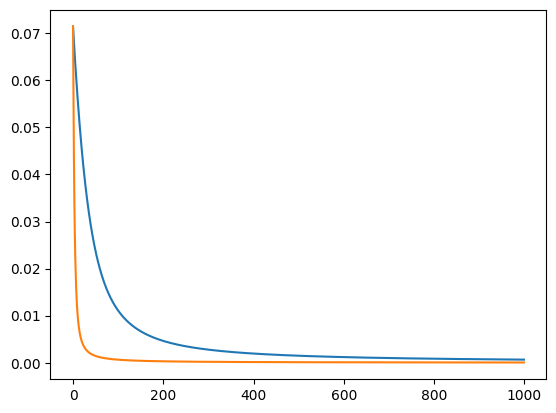

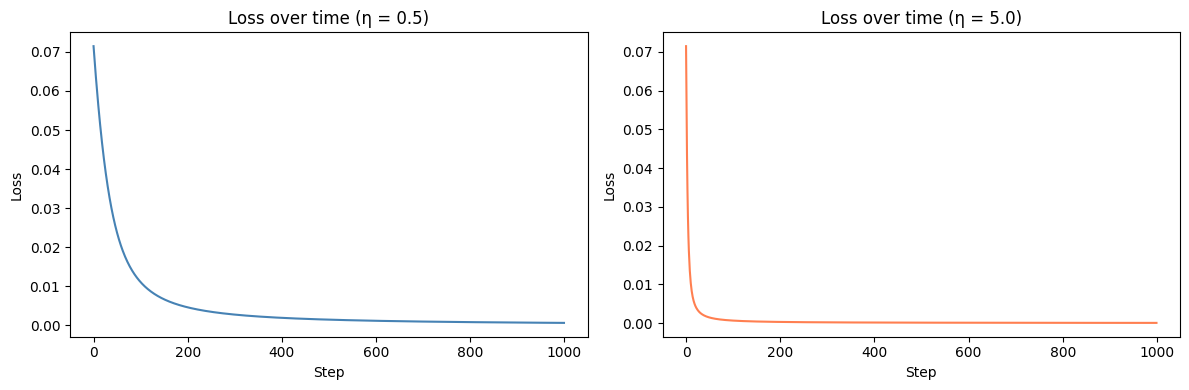

In [4]:
def train(lr, steps=1000):
    """Train the single-example network and return loss history."""
    x, y = 1.0, 1.0
    w1, w2 = 0.5, 0.8
    losses = []

    for _ in range(steps):
        # Forward pass
        z1 = w1 * x
        a1 = sigmoid(z1)
        z2 = w2 * a1
        a2 = sigmoid(z2)
        loss = 0.5 * (a2 - y) ** 2
        losses.append(loss)

        # TODO: Backward pass — copy your expressions from Q3 here
        delta2 = (a2 - y) * sigmoid_prime(z2)
        delta1 = (w2 * delta2) * sigmoid_prime(z1)
        grad_w2 = delta2 * a1
        grad_w1 = delta1 * x

        # TODO: Update weights
        w1 = w1 - lr * grad_w1
        w2 = w2 - lr * grad_w2

    return losses

# Plot for lr = 0.5
losses_slow = train(lr=0.5)
plt.plot(losses_slow)

# Plot for lr = 5.0
losses_fast = train(lr=5.0)
plt.plot(losses_fast)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_slow, color='steelblue')
axes[0].set_title('Loss over time (η = 0.5)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')

axes[1].plot(losses_fast, color='coral')
axes[1].set_title('Loss over time (η = 5.0)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

**Your written answer:**

*(Replace this text. What do the two curves look like, and what does that tell you about choosing a learning rate?)*

1. The shape of the loss curve for η = 0.5 is similar to an exponential decay, dropping quickly initially and then gradually flattens out as the loss approaches zero.This indicates that the network is smoothly and steadily converging toward the target value without any instability.

2. When η = 5.0, the loss still decreases smoothly, but it converges much faster to a significantly lower final loss than it does with η = 0.5.

3. Typically a very large learning rate (η = 5.0) causes oscillations or divergence. However, it works perfectly here because our targe is y = 1.0. since the sigmoid function can only approach 1.0 when its input goes to infinity, the network requiress large weight to get close to the target. Also since sigmoid function never exceeds 1.0, the error term (a2 - y) remains negative always and the weight is always updated in the same direction without overshooting or oscillating.



---
## Section B: Karpathy's Micrograd Lecture

Watch the video before attempting these questions: [YouTube link](https://www.youtube.com/watch?v=VMj-3S1tku0)

### Q5 📝 — What does a derivative actually tell us?

*(Timestamp: 00:08:08 — derivatives)*

Karpathy introduces derivatives by nudging inputs and observing the effect on the output.

In your own words, explain:
1. What does the derivative of a function at a point tell you?
2. If a neuron's weight has a **large positive gradient** with respect to the loss, should you **increase or decrease** that weight during gradient descent — and why?

> No equations required. Answer in 4–5 sentences.

**Your answer:**

1. The derivative tell how much the function changes for a small change in input.(i.e) How much sensitivity that the function has for some change in that variable.
2. If neuron's weight has large positive gradient w.r.t loss function, then we have to decrease the weight during gradient descent. Because the gradient is positive, increase in weight causes increse in cost and decrease in weight causes decrease in cost. So decreasing the weight causes the cost to decrease towards the minimum.

---
### Q6 📝 + 💻 — Trace gradients through a simple expression

*(Timestamp: 00:32:10 — manual backprop)*

Consider the expression: `L = (a + b) * c`, where **a = 2, b = −3, c = 4**.

**Tasks:**
1. In the markdown cell below, draw the computation graph with nodes for each operation and leaf nodes for a, b, c
2. Compute the forward pass: what is L?
3. Starting from ∂L/∂L = 1, manually backpropagate to find ∂L/∂a, ∂L/∂b, and ∂L/∂c
4. In the code cell, verify ∂L/∂a by nudging a by h = 0.001 and checking that [L(a+h) − L(a)] / h ≈ ∂L/∂a

**Your computation graph and manual gradients:**

```
# Draw your computation graph here, for example:
#
#   a=2  b=-3
#     \  /
#      (+)  <-- node: e = a + b
#       |  c=4
#       \  /
#        (*) <-- node: L = e * c
#        |
#        L

#  my Answer:
#  a=2  b=-3
#   \   /
#    (+)
#     |
#    e=-1  c=4
#      \   /
#       (*)
#        |
#       L=-4
```

**Forward pass:**
- e = a + b = -1
- L = e * c = -4

**Backward pass** (start from ∂L/∂L = 1):
- ∂L/∂c = -1 * 1 = -1  (hint: what does multiplying by e do?)
- ∂L/∂e = 4 * 1 = 4  (hint: what does multiplying by c do?)
- ∂L/∂a = 4 * 1 = 4  (chain rule through the + node)
- ∂L/∂b = 4 * 1 = 4

In [5]:
# Verify ∂L/∂a using the finite difference method
def L(a, b, c):
    return (a + b) * c

a, b, c = 2.0, -3.0, 4.0
h = 0.001

# Numerical gradient for a
grad_a_numerical = (L(a + h, b, c) - L(a, b, c)) / h

# Your analytical gradient from the manual backprop above
grad_a_analytical = 4  # TODO: fill in your answer

print(f"Numerical  ∂L/∂a = {grad_a_numerical:.4f}")
print(f"Analytical ∂L/∂a = {grad_a_analytical}")
print(f"Match: {abs(grad_a_numerical - grad_a_analytical) < 0.01 if grad_a_analytical is not None else 'Fill in grad_a_analytical first'}")

Numerical  ∂L/∂a = 4.0000
Analytical ∂L/∂a = 4
Match: True


---
### Q7 💻 — Extend the Value class with ReLU

*(Timestamp: 00:19:09 — Value object, and 01:27:05 — breaking up operations)*

A starter `Value` class supporting `+`, `*`, and `tanh` is provided below. Your tasks:
1. Add support for the **ReLU** operation — both the forward value and its `_backward` function
2. Test it: confirm `Value(-1.0).relu().data == 0` and `Value(2.0).relu().data == 2.0`
3. Call `.backward()` and print the gradient on both inputs. Explain in one sentence why the gradient for −1.0 is 0.

> **Hint:** ReLU passes the gradient through unchanged when input > 0, and blocks it (sets to 0) when input ≤ 0.

In [6]:
class Value:
    """A scalar value that supports automatic differentiation."""

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        # TODO: implement ReLU forward pass
        out = Value( max(0.0,self.data), (self,), 'relu')
        def _backward():
            self.grad += (self.data>0) * out.grad
        out._backward = _backward
        return out
        raise NotImplementedError("Implement relu() here!")

    def backward(self):
        """Topological sort then call _backward on each node."""
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other


# --- Test your implementation ---
a = Value(-1.0)
b = Value(2.0)

ra = a.relu()
rb = b.relu()

print(f"relu(-1.0) = {ra.data}  (expected 0)")
print(f"relu(2.0)  = {rb.data}  (expected 2.0)")

# Backprop through b (the positive case)
rb.backward()
print(f"\nGradient at b=2.0: {b.grad:.1f}  (expected 1.0)")

# Backprop through a (the negative case)
ra.backward()
print(f"Gradient at a=-1.0: {a.grad:.1f}  (expected 0.0)")

relu(-1.0) = 0.0  (expected 0)
relu(2.0)  = 2.0  (expected 2.0)

Gradient at b=2.0: 1.0  (expected 1.0)
Gradient at a=-1.0: 0.0  (expected 0.0)


**Why is the gradient for a = −1.0 equal to 0?**

*(Answer in one sentence.)*
The relu function is flat 0 at the negative region of input axis, so its derivative is 0 there.

---
### Q8 💻 + 📝 — Train a single neuron and observe it learn

*(Timestamp: 02:01:12 — gradient descent)*

Using the `Neuron` class provided below, train a single neuron to map inputs **(2.0, 3.0) → target 1.0** using 50 steps of gradient descent.

**Tasks:**
1. Print the final loss
2. Plot loss vs. step number
3. Answer in 2–3 sentences: at what point does the loss stop decreasing noticeably, and what does that suggest about what the neuron has "learned"?

> **Remember:** call `zero_grad()` before each backward pass — Karpathy explains why at ~2:10:00.

Final loss: 0.000005
Final prediction: 0.9969  (target was 1.0)


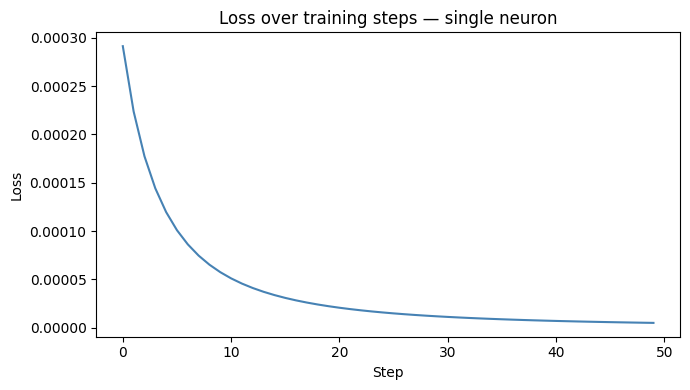

In [20]:
class Neuron:
    """A single neuron with 2 inputs, using the Value class for autograd."""
    def __init__(self):
        self.w1 = Value(np.random.uniform(-1, 1))
        self.w2 = Value(np.random.uniform(-1, 1))
        self.b  = Value(0.0)

    def __call__(self, x1, x2):
        # Linear combination + tanh activation
        act = self.w1 * Value(x1) + self.w2 * Value(x2) + self.b
        return act.tanh()

    def parameters(self):
        return [self.w1, self.w2, self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


np.random.seed(42)
neuron = Neuron()

x1, x2 = 2.0, 3.0   # inputs
target = 1.0          # desired output
lr = 0.1
losses = []

for step in range(50):
    # TODO: Forward pass
    pred = neuron(x1,x2)  # neuron(x1, x2)

    # TODO: Compute MSE loss using Value operations
    # loss = 0.5 * (pred - target)^2
    # Hint: Value supports +, *, and you can use Value(-1) to negate
    loss = Value(0.5) * (pred + Value(-1)*target) * (pred + Value(-1)*target)

    losses.append(loss.data if loss is not None else float('nan'))

    # TODO: Backward pass (remember zero_grad first!)
    neuron.zero_grad()
    pred.backward()
    # TODO: Update parameters
    for p in neuron.parameters():
      p.data += lr * p.grad

print(f"Final loss: {losses[-1]:.6f}")
print(f"Final prediction: {neuron(x1, x2).data:.4f}  (target was {target})")

plt.figure(figsize=(7, 4))
plt.plot(losses, color='steelblue')
plt.title('Loss over training steps — single neuron')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

**Your written answer:**

*(Replace this text. At what step does the loss roughly plateau? What does the final prediction value tell you about what the neuron has learned to do?)*

---
## 🎉 You're done!

Before submitting:
- [ ] All code cells run without errors
- [ ] All markdown cells with "Your answer" have been filled in
- [ ] Both plots in Q4 are visible
- [ ] The loss plot in Q8 is visible

**Further reading:** If you want to go deeper, Karpathy's full [nn-zero-to-hero](https://github.com/karpathy/nn-zero-to-hero) series continues from exactly where this assignment leaves off.